# E-Commerce Sales — Complete Data Science Workflow

**Author:** Ali Hassan  
**Role:** Data Engineer and Developer

## Project objective

This notebook demonstrates a complete, beginner-friendly data science workflow on the e-commerce sales dataset:

1. Business understanding
2. Data loading
3. Data inspection
4. Data cleaning and preprocessing
5. Feature engineering
6. Exploratory Data Analysis (EDA)
7. Business analysis
8. Problem definition for machine learning
9. Train/test split
10. Preprocessing pipeline
11. Model selection
12. Model building
13. Model evaluation
14. Feature importance
15. Final model
16. Example prediction
17. Saving the trained model
18. Real-life deployment checklist

> **Important:** The supplied dataset contains 5,000 rows and 12 original columns. The available schema includes order, customer, product category, region, quantity, price, discount, payment method, delivery days, rating, and revenue. It does **not** contain an age column, so this notebook does not invent one.

## 1. Business understanding

Before writing machine-learning code, first ask:

**What business problem are we solving?**

For this project we will use two levels of analysis:

### Descriptive / diagnostic analysis
We want to understand:
- Which product categories generate the most revenue?
- Which regions perform best?
- How does revenue change over time?
- Which payment methods are commonly used?
- How are delivery time and customer ratings distributed?

### Predictive analysis
We will build a regression model to predict **delivery_days** from information that can be known around the time of an order.

### Why not predict revenue?

Revenue in this dataset is mathematically derived from `quantity`, `unit_price`, and `discount`:

`revenue = quantity × unit_price × (1 - discount)`

Therefore, using those same fields to predict revenue would create a trivial target-leakage problem rather than a useful machine-learning exercise.

## 2. Import libraries

We use:
- **Pandas** for data manipulation
- **NumPy** for numerical operations
- **Matplotlib / Seaborn** for visualization
- **Scikit-learn** for preprocessing, model selection, and evaluation
- **Joblib** for saving the trained model

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.model_selection import TimeSeriesSplit, cross_val_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load the dataset

### Teaching point

A notebook should not depend on one person's Windows path.

The original notebook used a local path such as:

`E:\2026\Data Science Instructore\...\ecommerce_sales_analytics_5000.csv`

That path will not work on another computer.

So we use a small configuration section. Change only `DATA_PATH` if the CSV is stored somewhere else.

In [4]:
# ============================================================
# DATA PATH
# ============================================================

# Option 1: Put the CSV in the same folder as this notebook.
DATA_PATH = Path(r"E:\2026\Data Science Instructore\Grow  in DS\Grow  in DS\Data Sets\ecommerce_sales_analytics_5000.csv")
df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully: {DATA_PATH}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Dataset loaded successfully: E:\2026\Data Science Instructore\Grow  in DS\Grow  in DS\Data Sets\ecommerce_sales_analytics_5000.csv
Rows: 5,000
Columns: 12


## 4. First look at the data

Always inspect the data before cleaning or modeling.

The main questions are:
- How many rows and columns are there?
- What are the column names?
- What data types are present?
- Are there missing values?
- Are there duplicate records?

In [5]:
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nData types and non-null counts:")
df.info()

Shape: (5000, 12)

Column names:
['order_id', 'order_date', 'customer_id', 'product_category', 'region', 'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days', 'customer_rating', 'revenue']

First 5 rows:


,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.70,"1,883.20"
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.90,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.50,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.60,"2,569.90"
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.90,468.56



Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   str    
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   str    
 4   region            5000 non-null   str    
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   str    
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), str(4)
memory usage: 593.2 KB


## 5. Data quality audit

A good preprocessing workflow checks:
- missing values
- duplicate rows
- duplicate IDs
- unique values
- impossible values
- invalid dates
- numerical ranges
- categorical values

**Important:** A data scientist should diagnose a problem before deciding how to fix it.

In [6]:
# Missing values
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_pct
})

display(missing_report)

# Duplicates
print("Duplicate rows:", df.duplicated().sum())

if "order_id" in df.columns:
    print("Duplicate order IDs:", df["order_id"].duplicated().sum())

# Unique values
print("\nUnique values per column:")
display(df.nunique().sort_values())

,missing_count,missing_percent
order_id,0,0.00
order_date,0,0.00
customer_id,0,0.00
product_category,0,0.00
region,0,0.00
quantity,0,0.00
unit_price,0,0.00
discount,0,0.00
payment_method,0,0.00
delivery_days,0,0.00


Duplicate rows: 0
Duplicate order IDs: 0

Unique values per column:


payment_method         3
product_category       4
region                 4
quantity               7
delivery_days         11
discount              36
customer_rating       41
customer_id          989
unit_price          4788
revenue             4940
order_date          5000
order_id            5000
dtype: int64

## 6. Standardize column names

Consistent column names make code easier to read and reduce errors.

We:
- remove leading/trailing spaces
- convert names to lowercase
- replace spaces with underscores

In [7]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(r"\s+", "_", regex=True)
)

print(df.columns.tolist())

['order_id', 'order_date', 'customer_id', 'product_category', 'region', 'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days', 'customer_rating', 'revenue']


## 7. Convert data types

`order_date` is originally read as text.

A date should be converted to a real datetime type so we can extract:
- year
- month
- quarter
- day of week

`errors="coerce"` converts invalid dates to `NaT`, which can then be detected and handled.

In [8]:
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

print("Invalid dates:", df["order_date"].isna().sum())
print("Date range:", df["order_date"].min(), "to", df["order_date"].max())

Invalid dates: 0
Date range: 2022-01-01 00:00:00 to 2035-09-09 00:00:00


## 8. Validate business rules

This is more important than simply checking `isnull()`.

For this dataset:
- quantity should be positive
- unit price should be positive
- discount should normally be between 0 and 1
- delivery days should be positive
- customer rating should be between 1 and 5
- revenue should not be negative

We report suspicious records first. We do not blindly delete data.

In [9]:
business_checks = {
    "quantity <= 0": (df["quantity"] <= 0).sum(),
    "unit_price <= 0": (df["unit_price"] <= 0).sum(),
    "discount outside [0, 1]": (~df["discount"].between(0, 1)).sum(),
    "delivery_days <= 0": (df["delivery_days"] <= 0).sum(),
    "customer_rating outside [1, 5]": (~df["customer_rating"].between(1, 5)).sum(),
    "revenue < 0": (df["revenue"] < 0).sum(),
}

pd.Series(business_checks, name="problem_count")

quantity <= 0                     0
unit_price <= 0                   0
discount outside [0, 1]           0
delivery_days <= 0                0
customer_rating outside [1, 5]    0
revenue < 0                       0
Name: problem_count, dtype: int64

## 9. Remove exact duplicate rows

If the same complete record appears more than once, it can distort counts and averages.

We keep the first occurrence and report how many rows were removed.

In [10]:
before = len(df)

df = df.drop_duplicates().copy()

removed = before - len(df)

print(f"Rows before: {before:,}")
print(f"Duplicate rows removed: {removed:,}")
print(f"Rows after: {len(df):,}")

Rows before: 5,000
Duplicate rows removed: 0
Rows after: 5,000


## 10. Handle missing values

This dataset is expected to be complete based on the supplied notebook audit, but production code should still handle missing values safely.

For modeling:
- numerical columns → median imputation
- categorical columns → most-frequent imputation

This is implemented later inside a **Pipeline**, which prevents preprocessing from accidentally learning from the test set.

## 11. Feature engineering

Feature engineering means creating useful variables from existing information.

We create:
- `order_year`
- `order_month`
- `order_quarter`
- `order_day`
- `day_of_week`
- `gross_sales`
- `discount_amount`
- `net_sales`

### Important business formula

`gross_sales = quantity × unit_price`

`discount_amount = gross_sales × discount`

`net_sales = gross_sales - discount_amount`

The supplied `revenue` should correspond to the final net sales value, subject to rounding/data-quality differences.

In [11]:

# Date features
df["order_year"] = df["order_date"].dt.year
df["order_month"] = df["order_date"].dt.month
df["order_quarter"] = df["order_date"].dt.quarter
df["order_day"] = df["order_date"].dt.day
df["day_of_week"] = df["order_date"].dt.day_name()


In [12]:

# Business features
df["gross_sales"] = df["quantity"] * df["unit_price"]
df["discount_amount"] = df["gross_sales"] * df["discount"]
df["net_sales"] = df["gross_sales"] - df["discount_amount"]


In [15]:

# Check how closely the supplied revenue follows the formula
df["revenue_difference"] = df["revenue"] - df["net_sales"]

print("Maximum absolute difference between revenue and calculated net sales:",
      df["revenue_difference"].abs().max().round(4))

display(df.head())


Maximum absolute difference between revenue and calculated net sales: 0.005


,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,order_year,order_month,order_quarter,order_day,day_of_week,gross_sales,discount_amount,net_sales,revenue_difference
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.70,"1,883.20",2022,1,1,1,Saturday,"2,615.55",732.35,"1,883.20",0.00
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,3.90,304.10,2022,1,1,2,Sunday,334.18,30.08,304.10,-0.00
2,10003,2022-01-03,1860,Beauty,East,3,311.28,0.31,COD,6,2.50,644.35,2022,1,1,3,Monday,933.84,289.49,644.35,0.00
3,10004,2022-01-04,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.60,"2,569.90",2022,1,1,4,Tuesday,"2,622.35",52.45,"2,569.90",-0.00
4,10005,2022-01-05,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.90,468.56,2022,1,1,5,Wednesday,699.35,230.79,468.56,-0.00


## 12. Final cleaning decision

For analysis and modeling:
- invalid dates are removed because date information is essential
- invalid business-rule records are removed only if they exist
- exact duplicate rows are removed
- derived helper columns used only for validation are not used as model inputs

Because the supplied dataset has 5,000 complete records and the original audit reported no missing or duplicate rows, the cleaning stage should normally remove little or no valid business data.

In [16]:
# Remove records with invalid essential fields.
df = df.dropna(subset=[
    "order_date",
    "product_category",
    "region",
    "quantity",
    "unit_price",
    "discount",
    "payment_method",
    "delivery_days",
    "customer_rating",
    "revenue"
]).copy()

# Keep only records satisfying the defined business rules.
valid_mask = (
    (df["quantity"] > 0) &
    (df["unit_price"] > 0) &
    (df["discount"].between(0, 1)) &
    (df["delivery_days"] > 0) &
    (df["customer_rating"].between(1, 5)) &
    (df["revenue"] >= 0)
)

df = df.loc[valid_mask].copy()

# Sort by date for time-based analysis.
df = df.sort_values("order_date").reset_index(drop=True)

print("Clean dataset shape:", df.shape)
print("Missing values remaining:", int(df.isna().sum().sum()))

Clean dataset shape: (5000, 21)
Missing values remaining: 0


## 13. Exploratory Data Analysis (EDA)

EDA helps us understand the dataset before making business or machine-learning decisions.

We will examine:
- numerical distributions
- category performance
- regional performance
- payment methods
- revenue trends
- delivery days
- customer ratings

In [17]:
numeric_cols = [
    "quantity",
    "unit_price",
    "discount",
    "delivery_days",
    "customer_rating",
    "revenue"
]

display(df[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
quantity,"5,000.00",4.04,2.02,1.00,2.00,4.00,6.00,7.00
unit_price,"5,000.00",308.42,169.26,15.15,161.90,309.89,455.56,599.96
discount,"5,000.00",0.18,0.10,0.00,0.09,0.18,0.27,0.35
delivery_days,"5,000.00",6.12,3.15,1.00,3.00,6.00,9.00,11.00
customer_rating,"5,000.00",2.97,1.16,1.00,2.00,3.00,4.00,5.00
revenue,"5,000.00","1,021.96",825.58,11.21,354.53,796.65,"1,515.69","4,119.33"


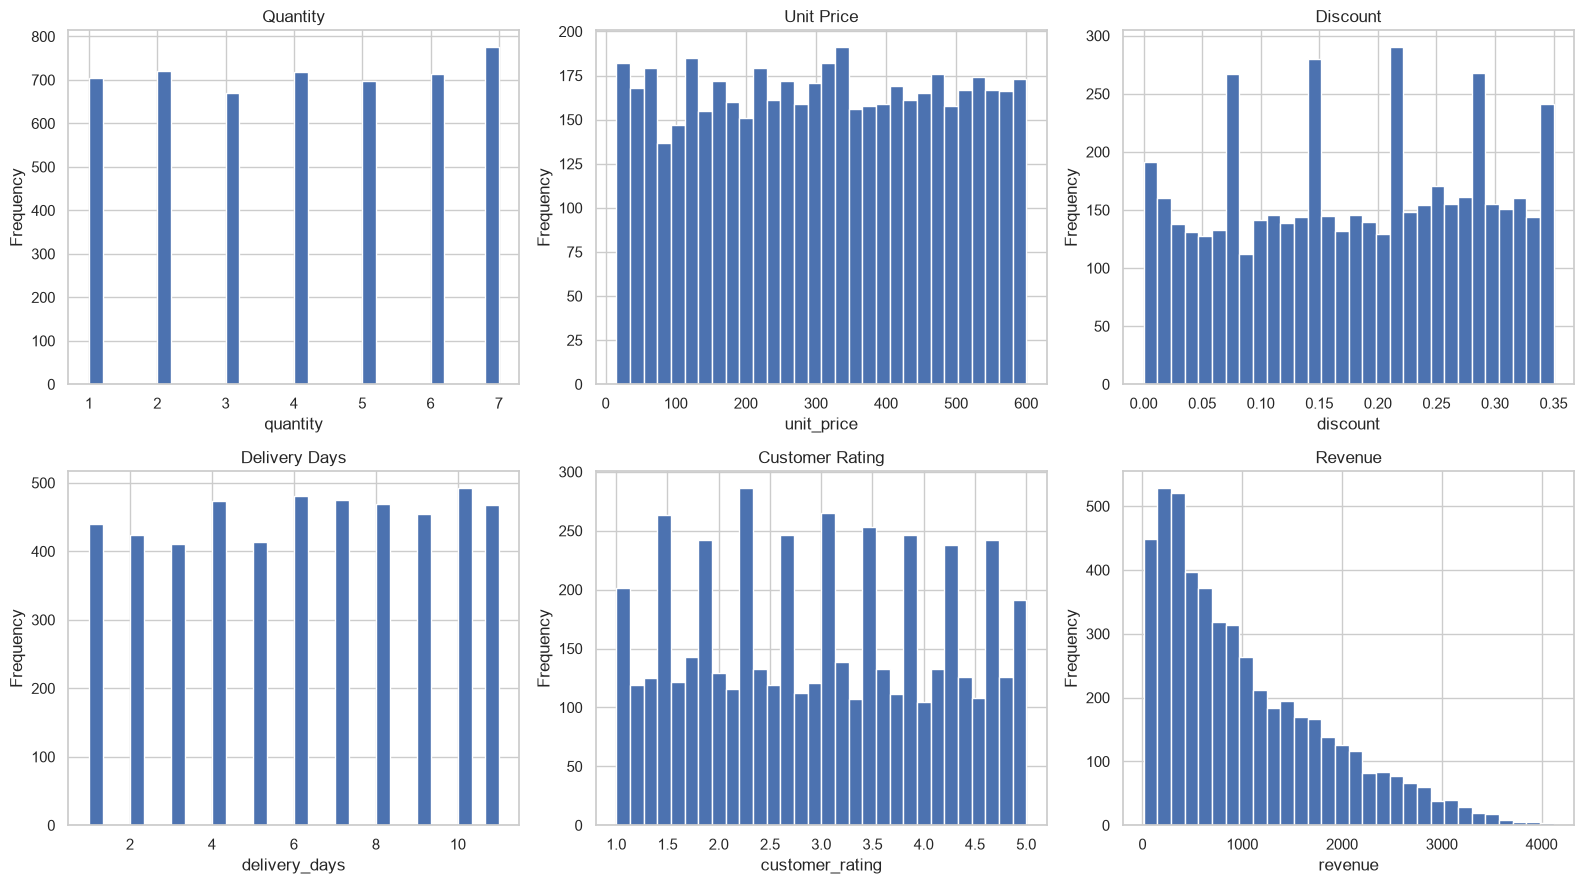

In [18]:
# Distribution of key numerical variables
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.flat, numeric_cols):
    ax.hist(df[col], bins=30)
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 14. Category analysis

A basic business question is:

**Which product category generates the most revenue?**

We calculate both total revenue and average revenue per order.

Remember:

- **sum** answers "How much revenue?"
- **mean** answers "What is the average revenue per order?"

In [19]:
category_summary = (
    df.groupby("product_category")
      .agg(
          total_revenue=("revenue", "sum"),
          average_revenue=("revenue", "mean"),
          total_quantity=("quantity", "sum"),
          orders=("order_id", "count")
      )
      .sort_values("total_revenue", ascending=False)
)

display(category_summary.round(2))

,total_revenue,average_revenue,total_quantity,orders
product_category,,,,
Electronics,"1,829,899.22","1,029.77",7109,1777
Clothing,"1,531,931.72","1,000.61",6171,1531
Home,"982,083.92","1,013.50",3949,969
Beauty,"765,860.88","1,059.28",2995,723


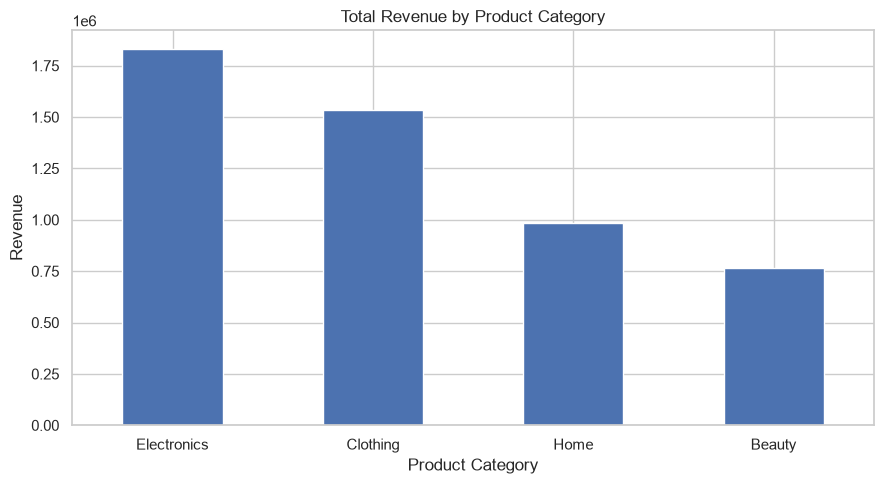

In [20]:
category_summary["total_revenue"].plot(
    kind="bar",
    figsize=(9, 5),
    title="Total Revenue by Product Category"
)

plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 15. Regional analysis

We compare revenue and order performance across regions.

This is useful for:
- regional sales strategy
- inventory planning
- marketing decisions
- identifying high-performing markets

In [21]:
region_summary = (
    df.groupby("region")
      .agg(
          total_revenue=("revenue", "sum"),
          average_revenue=("revenue", "mean"),
          orders=("order_id", "count"),
          average_delivery_days=("delivery_days", "mean"),
          average_rating=("customer_rating", "mean")
      )
      .sort_values("total_revenue", ascending=False)
)

display(region_summary.round(2))

,total_revenue,average_revenue,orders,average_delivery_days,average_rating
region,,,,,
West,"1,345,582.16","1,043.90",1289,6.08,2.96
North,"1,281,508.45","1,004.32",1276,6.12,2.99
South,"1,246,640.90","1,031.99",1208,6.17,2.97
East,"1,236,044.23","1,007.37",1227,6.10,2.97


## 16. Revenue by category and region

A pivot table summarizes multiple dimensions at once.

This is similar to the analysis already started in the supplied notebook, but here we make the grouping explicit and easy to reuse.

In [22]:
category_region = pd.pivot_table(
    df,
    values="revenue",
    index="product_category",
    columns="region",
    aggfunc=["sum", "mean"]
)

display(category_region.round(2))

sum                                      mean  \
region                 East      North      South       West     East   
product_category                                                        
Beauty           174,909.11 186,213.32 191,073.98 213,664.47 1,060.06   
Clothing         402,582.60 364,659.43 348,363.14 416,326.55 1,019.20   
Electronics      411,803.35 472,450.93 487,055.68 458,589.26   985.18   
Home             246,749.17 258,184.77 220,148.10 257,001.88   990.96   

                                             
region              North    South     West  
product_category                             
Beauty             959.86 1,110.90 1,112.84  
Clothing           964.71   954.42 1,059.36  
Electronics      1,022.62 1,070.45 1,037.53  
Home             1,066.88 1,019.20   980.92

## 17. Yearly revenue analysis

The dataset covers multiple years, so yearly aggregation can reveal growth or decline.

We calculate:
- total yearly revenue
- average order revenue
- number of orders

In [23]:
yearly_summary = (
    df.groupby("order_year")
      .agg(
          total_revenue=("revenue", "sum"),
          average_revenue=("revenue", "mean"),
          orders=("order_id", "count")
      )
      .reset_index()
)

display(yearly_summary.round(2))

,order_year,total_revenue,average_revenue,orders
0,2022,"371,824.30","1,018.70",365
1,2023,"365,915.79","1,002.51",365
2,2024,"363,209.13",992.37,366
3,2025,"349,802.33",958.36,365
4,2026,"386,369.69","1,058.55",365
5,2027,"386,151.91","1,057.95",365
6,2028,"376,844.80","1,029.63",366
7,2029,"359,239.24",984.22,365
8,2030,"387,884.46","1,062.70",365
9,2031,"365,250.83","1,000.69",365


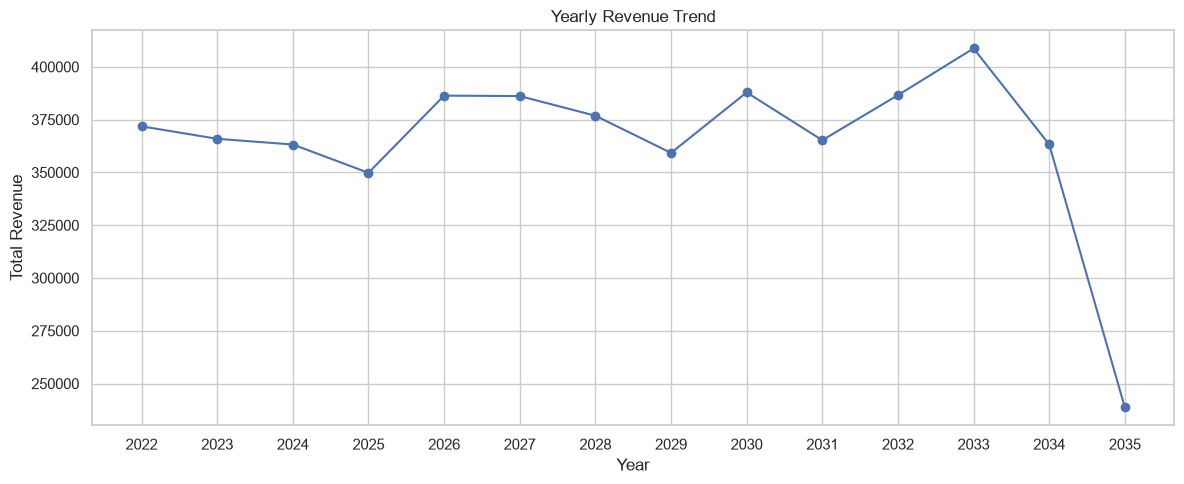

In [24]:
plt.figure(figsize=(12, 5))

plt.plot(
    yearly_summary["order_year"],
    yearly_summary["total_revenue"],
    marker="o"
)

plt.title("Yearly Revenue Trend")
plt.xlabel("Year")
plt.ylabel("Total Revenue")
plt.xticks(yearly_summary["order_year"])
plt.tight_layout()
plt.show()

## 18. Monthly seasonality

A common business question is:

**Which months tend to generate more revenue?**

We aggregate by month number so January is compared with January across all years.

In [25]:
monthly_summary = (
    df.groupby("order_month")
      .agg(
          total_revenue=("revenue", "sum"),
          average_revenue=("revenue", "mean"),
          orders=("order_id", "count")
      )
      .reset_index()
)

display(monthly_summary.round(2))

,order_month,total_revenue,average_revenue,orders
0,1,"426,374.92",982.43,434
1,2,"413,890.24","1,047.82",395
2,3,"425,050.52",979.38,434
3,4,"398,715.16",949.32,420
4,5,"479,772.55","1,105.47",434
5,6,"442,941.58","1,054.62",420
6,7,"440,570.72","1,015.14",434
7,8,"460,874.78","1,061.92",434
8,9,"402,368.11","1,008.44",399
9,10,"407,873.12","1,012.09",403


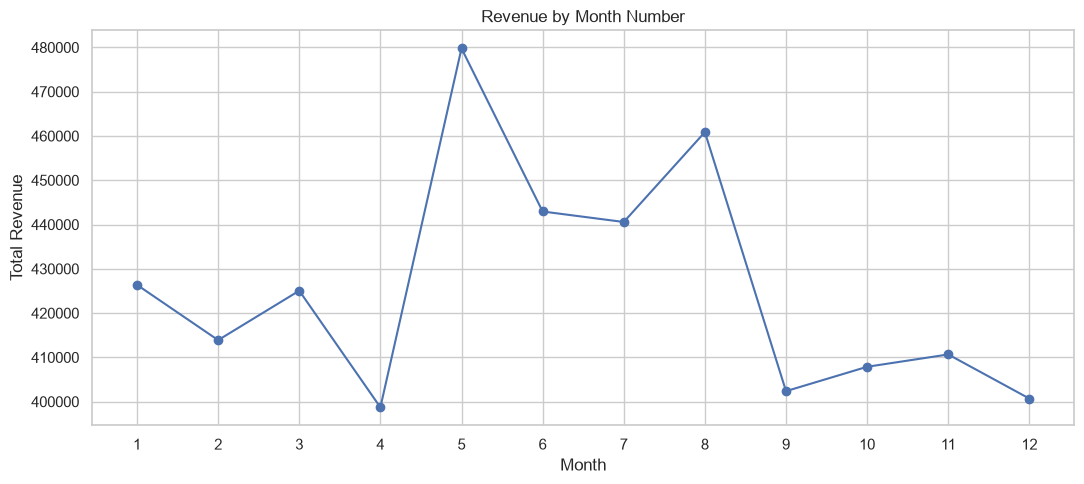

In [26]:
plt.figure(figsize=(11, 5))

plt.plot(
    monthly_summary["order_month"],
    monthly_summary["total_revenue"],
    marker="o"
)

plt.title("Revenue by Month Number")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

## 19. Payment-method analysis

Payment method can help the business understand customer preferences.

In [27]:
payment_summary = (
    df.groupby("payment_method")
      .agg(
          orders=("order_id", "count"),
          total_revenue=("revenue", "sum"),
          average_revenue=("revenue", "mean"),
          average_rating=("customer_rating", "mean")
      )
      .sort_values("orders", ascending=False)
)

display(payment_summary.round(2))

,orders,total_revenue,average_revenue,average_rating
payment_method,,,,
Card,2270,"2,366,248.20","1,042.40",3.02
COD,1774,"1,788,408.44","1,008.12",2.94
Wallet,956,"955,119.10",999.08,2.93


## 20. Delivery and customer-rating analysis

Operational performance can influence customer experience.

We compare:
- average delivery time
- average customer rating
- rating by delivery duration

This is **association**, not proof of causation.

In [28]:
delivery_rating = (
    df.groupby("delivery_days")
      .agg(
          orders=("order_id", "count"),
          average_rating=("customer_rating", "mean"),
          average_revenue=("revenue", "mean")
      )
      .reset_index()
)

display(delivery_rating.round(2))

,delivery_days,orders,average_rating,average_revenue
0,1,440,2.99,975.30
1,2,424,2.94,"1,024.65"
2,3,410,2.93,983.92
3,4,474,3.07,"1,086.91"
4,5,413,3.04,979.95
5,6,481,2.96,"1,050.91"
6,7,475,3.02,"1,056.27"
7,8,469,2.99,"1,026.42"
8,9,455,2.95,"1,032.44"
9,10,492,2.92,995.14


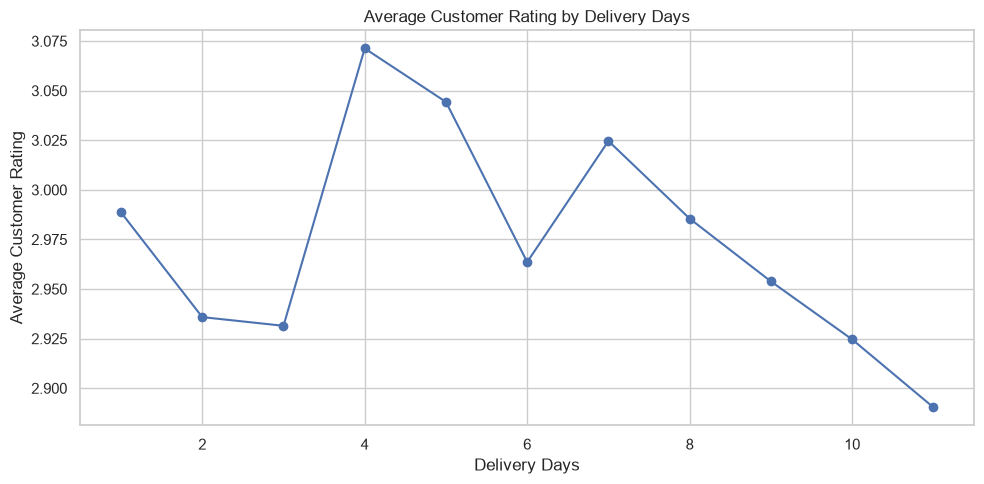

In [29]:
plt.figure(figsize=(10, 5))

plt.plot(
    delivery_rating["delivery_days"],
    delivery_rating["average_rating"],
    marker="o"
)

plt.title("Average Customer Rating by Delivery Days")
plt.xlabel("Delivery Days")
plt.ylabel("Average Customer Rating")
plt.tight_layout()
plt.show()

## 21. Correlation analysis

Correlation measures the strength and direction of a linear relationship between numerical variables.

It does **not** prove causation.

We exclude ID fields because identifiers usually do not have meaningful numeric relationships with business outcomes.

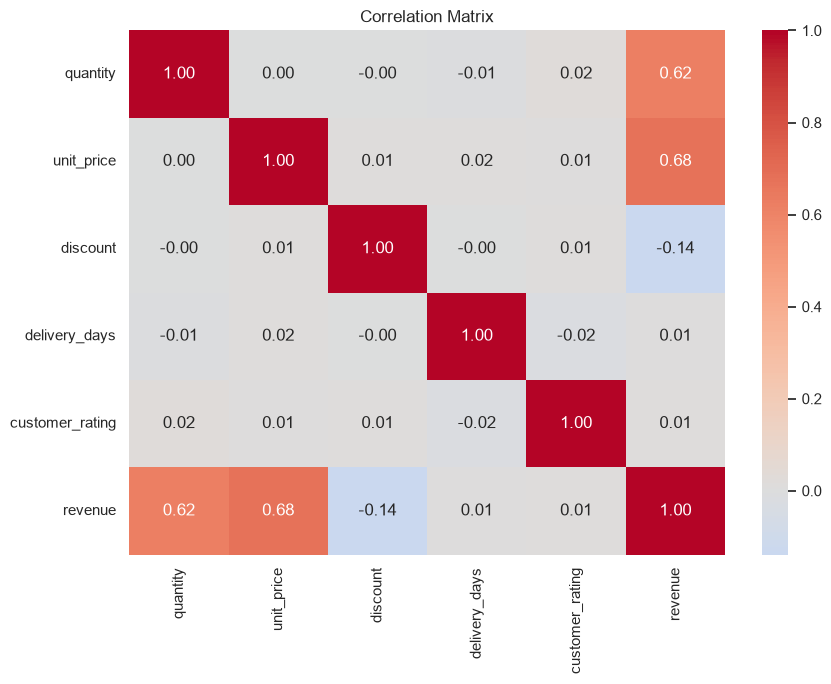

In [30]:
corr_cols = [
    "quantity",
    "unit_price",
    "discount",
    "delivery_days",
    "customer_rating",
    "revenue"
]

plt.figure(figsize=(9, 7))
sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# Machine Learning Section

## 22. Define the prediction problem

### Target

We will predict:

`delivery_days`

### Why?

`delivery_days` is an operational outcome that can be useful for:
- estimating delivery time
- identifying orders likely to require attention
- improving logistics planning

### Features

We use fields that can reasonably be known at order time:

**Numerical**
- quantity
- unit_price
- discount
- order_year
- order_month
- order_quarter
- order_day

**Categorical**
- product_category
- region
- payment_method

### Features we intentionally do NOT use

- `order_id` → identifier
- `customer_id` → identifier with no demonstrated stable predictive meaning
- `delivery_days` → target itself
- `revenue` → can be derived from order inputs and is not needed
- `customer_rating` → typically known after delivery, so using it would leak future information
- `day_of_week` → omitted from the first model for simplicity, though it could be added if operationally justified

In [31]:
TARGET = "delivery_days"

FEATURES = [
    "quantity",
    "unit_price",
    "discount",
    "order_year",
    "order_month",
    "order_quarter",
    "order_day",
    "product_category",
    "region",
    "payment_method"
]

X = df[FEATURES].copy()
y = df[TARGET].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures:")
print(FEATURES)

Feature matrix shape: (5000, 10)
Target shape: (5000,)

Features:
['quantity', 'unit_price', 'discount', 'order_year', 'order_month', 'order_quarter', 'order_day', 'product_category', 'region', 'payment_method']


## 23. Train/test split

Because this is order data with a date field, a chronological split is more realistic than randomly mixing old and future records.

We use:
- first 80% of time-ordered records → training
- final 20% → testing

This better simulates real life:

**Train on the past → predict the future.**

In [32]:
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTraining period:")
print(df["order_date"].iloc[0], "to", df["order_date"].iloc[split_index - 1])

print("\nTesting period:")
print(df["order_date"].iloc[split_index], "to", df["order_date"].iloc[-1])

Training rows: 4000
Testing rows: 1000

Training period:
2022-01-01 00:00:00 to 2032-12-13 00:00:00

Testing period:
2032-12-14 00:00:00 to 2035-09-09 00:00:00


## 24. Build the preprocessing pipeline

Machine-learning models need numerical inputs.

We therefore:
- fill missing numerical values with the median
- standardize numerical values where appropriate
- fill missing categorical values with the most frequent value
- one-hot encode categorical variables

Putting preprocessing inside a `Pipeline` is a real-world best practice because the transformation is learned only from training data.

In [33]:
numeric_features = [
    "quantity",
    "unit_price",
    "discount",
    "order_year",
    "order_month",
    "order_quarter",
    "order_day"
]

categorical_features = [
    "product_category",
    "region",
    "payment_method"
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


## 25. Model selection

We compare three regression algorithms:

1. **Linear Regression**
   - simple baseline
   - easy to explain
   - assumes mostly linear relationships

2. **Random Forest Regressor**
   - captures nonlinear relationships
   - handles mixed feature patterns well
   - less sensitive to feature scaling

3. **Gradient Boosting Regressor**
   - builds models sequentially
   - often performs strongly on tabular data
   - can capture complex relationships

### Evaluation metrics

- **MAE**: average absolute prediction error, in delivery days
- **RMSE**: penalizes larger errors more strongly
- **R²**: proportion of variance explained; higher is generally better

In [34]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

pipelines = {
    name: Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    for name, model in models.items()
}

print("Models prepared:")
for name in pipelines:
    print("-", name)

Models prepared:
- Linear Regression
- Random Forest
- Gradient Boosting


## 26. Cross-validation for model selection

We use `TimeSeriesSplit` so validation respects time order.

This is preferable to ordinary random cross-validation when future information should not be allowed to influence earlier validation periods.

We compare models using **negative MAE** because scikit-learn's scoring convention expects higher scores to be better.

In [35]:
tscv = TimeSeriesSplit(n_splits=5)

cv_results = []

for name, pipeline in pipelines.items():
    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=tscv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )

    mae_scores = -scores

    cv_results.append({
        "model": name,
        "mean_cv_mae": mae_scores.mean(),
        "std_cv_mae": mae_scores.std()
    })

cv_results_df = (
    pd.DataFrame(cv_results)
      .sort_values("mean_cv_mae")
      .reset_index(drop=True)
)

display(cv_results_df.round(4))

best_model_name = cv_results_df.loc[0, "model"]
print("Selected model:", best_model_name)

,model,mean_cv_mae,std_cv_mae
0,Linear Regression,2.71,0.06
1,Random Forest,2.74,0.05
2,Gradient Boosting,2.74,0.06


Selected model: Linear Regression


## 27. Build the selected model

Now we train the best model on the complete training set.

The preprocessing and model remain together in one pipeline.

In [36]:
best_pipeline = pipelines[best_model_name]

best_pipeline.fit(X_train, y_train)

print(f"{best_model_name} trained successfully.")

Linear Regression trained successfully.


## 28. Evaluate the final model on unseen data

The test set has not been used during model selection.

This gives us a more honest estimate of real-world performance.

### Interpretation

If MAE = 1.20, for example, the model is wrong by about **1.2 delivery days on average**.

RMSE gives more weight to large mistakes.

R² is useful for understanding explained variance but should not be used alone.

In [37]:
y_pred = best_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

evaluation = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [mae, rmse, r2]
})

display(evaluation.round(4))

,Metric,Value
0,MAE,2.80
1,RMSE,3.22
2,R²,-0.01


## 29. Compare actual vs predicted values

A useful diagnostic is to inspect actual and predicted delivery times side by side.

In [38]:
comparison = pd.DataFrame({
    "actual_delivery_days": y_test.values,
    "predicted_delivery_days": y_pred
})

comparison["absolute_error"] = (
    comparison["actual_delivery_days"]
    - comparison["predicted_delivery_days"]
).abs()

display(comparison.head(20).round(2))

,actual_delivery_days,predicted_delivery_days,absolute_error
0,6,6.07,0.07
1,9,6.22,2.78
2,5,6.18,1.18
3,8,6.06,1.94
4,11,6.04,4.96
5,10,6.03,3.97
6,11,6.00,5.00
7,9,6.19,2.81
8,10,6.14,3.86
9,10,5.84,4.16


## 30. Prediction diagnostic plot

A strong model should place predictions reasonably close to the diagonal line.

The farther points are from the line, the larger the prediction errors.

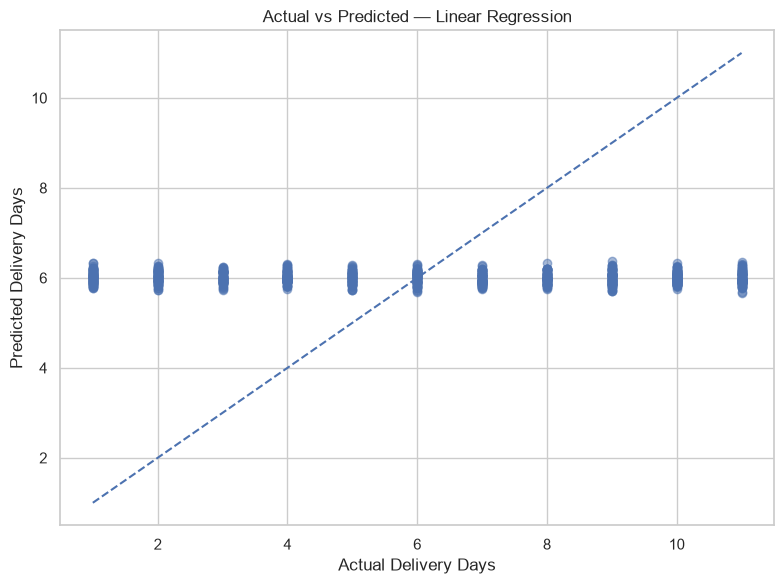

In [39]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Delivery Days")
plt.ylabel("Predicted Delivery Days")
plt.title(f"Actual vs Predicted — {best_model_name}")
plt.tight_layout()
plt.show()

## 31. Residual analysis

A residual is:

`actual - predicted`

Residuals help us find:
- systematic errors
- unusually large mistakes
- patterns the model has not learned

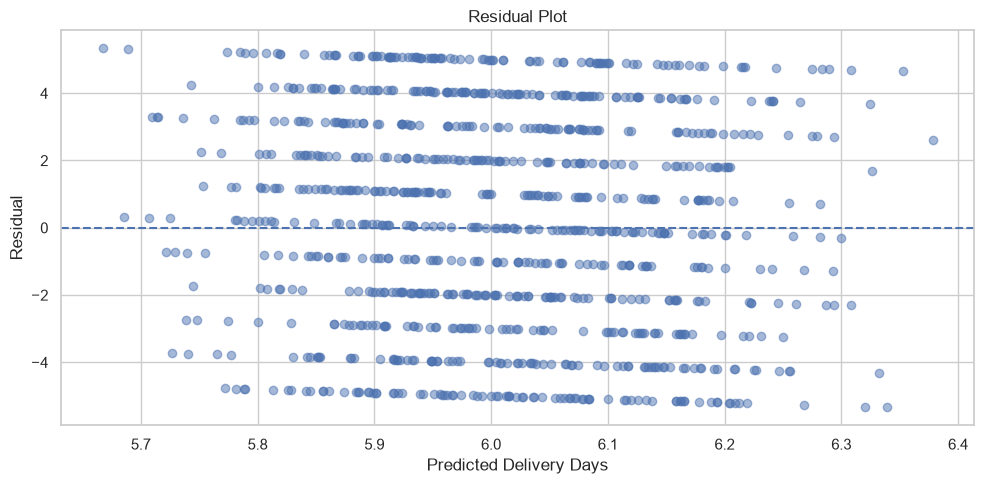

In [40]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 5))

plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Delivery Days")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

## 32. Feature importance

Tree-based models can provide feature importance.

For a one-hot encoded pipeline, the transformed feature names are obtained from the preprocessing step.

If the selected model is not tree-based, feature importance is skipped and the notebook reports that limitation.

In [41]:
model = best_pipeline.named_steps["model"]
fitted_preprocessor = best_pipeline.named_steps["preprocessor"]

if hasattr(model, "feature_importances_"):
    feature_names = fitted_preprocessor.get_feature_names_out()
    importances = model.feature_importances_

    importance_df = (
        pd.DataFrame({
            "feature": feature_names,
            "importance": importances
        })
        .sort_values("importance", ascending=False)
        .head(20)
    )

    display(importance_df)

    plt.figure(figsize=(10, 7))
    plt.barh(
        importance_df["feature"][::-1],
        importance_df["importance"][::-1]
    )
    plt.title(f"Top Feature Importances — {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print(
        f"{best_model_name} does not expose tree-based feature_importances_. "
        "Use model coefficients or permutation importance for deeper interpretation."
    )

Linear Regression does not expose tree-based feature_importances_. Use model coefficients or permutation importance for deeper interpretation.


## 33. Create a reusable prediction function

In real life, we should not repeat preprocessing manually.

The trained pipeline already knows how to:
- impute values
- scale numerical data
- encode categories
- make predictions

That makes the model easier to reuse in an application or API.

In [42]:
def predict_delivery_days(
    quantity,
    unit_price,
    discount,
    order_date,
    product_category,
    region,
    payment_method
):
    order_date = pd.to_datetime(order_date)

    input_data = pd.DataFrame([{
        "quantity": quantity,
        "unit_price": unit_price,
        "discount": discount,
        "order_year": order_date.year,
        "order_month": order_date.month,
        "order_quarter": order_date.quarter,
        "order_day": order_date.day,
        "product_category": product_category,
        "region": region,
        "payment_method": payment_method
    }])

    prediction = best_pipeline.predict(input_data)[0]

    return max(0, float(prediction))


# Example prediction
example_prediction = predict_delivery_days(
    quantity=5,
    unit_price=250,
    discount=0.10,
    order_date="2035-09-10",
    product_category="Electronics",
    region="West",
    payment_method="Card"
)

print(f"Predicted delivery time: {example_prediction:.2f} days")

Predicted delivery time: 5.79 days


## 34. Save the complete model pipeline

For real-world use, save the **entire pipeline**, not only the estimator.

This is important because the model depends on the same preprocessing steps used during training.

In [ ]:
MODEL_PATH = Path("ecommerce_delivery_model.joblib")

joblib.dump(best_pipeline, MODEL_PATH)

print(f"Model saved to: {MODEL_PATH.resolve()}")

## 35. Load the model and test it

This simulates what another Python program or API would do later.

In [ ]:
loaded_model = joblib.load(MODEL_PATH)

loaded_prediction = loaded_model.predict(pd.DataFrame([{
    "quantity": 5,
    "unit_price": 250,
    "discount": 0.10,
    "order_year": 2035,
    "order_month": 9,
    "order_quarter": 3,
    "order_day": 10,
    "product_category": "Electronics",
    "region": "West",
    "payment_method": "Card"
}]))[0]

print(f"Loaded model prediction: {loaded_prediction:.2f} days")

# Final Business Summary

## 36. Automatically generate key findings

The following section converts the analysis into a small management-style summary.

**Teaching point:** Data science is not only about models. The final goal is to turn data into decisions.

In [43]:
top_category = category_summary.index[0]
top_category_revenue = category_summary.iloc[0]["total_revenue"]

top_region = region_summary.index[0]
top_region_revenue = region_summary.iloc[0]["total_revenue"]

best_month = monthly_summary.loc[
    monthly_summary["total_revenue"].idxmax(),
    "order_month"
]

overall_avg_rating = df["customer_rating"].mean()
overall_avg_delivery = df["delivery_days"].mean()

print("BUSINESS SUMMARY")
print("-" * 60)
print(f"Top revenue category: {top_category}")
print(f"Revenue from top category: {top_category_revenue:,.2f}")
print(f"Top revenue region: {top_region}")
print(f"Revenue from top region: {top_region_revenue:,.2f}")
print(f"Highest-revenue month number: {int(best_month)}")
print(f"Average customer rating: {overall_avg_rating:.2f} / 5")
print(f"Average delivery time: {overall_avg_delivery:.2f} days")
print(f"Best ML model by CV MAE: {best_model_name}")
print(f"Test MAE: {mae:.2f} days")
print(f"Test RMSE: {rmse:.2f} days")
print(f"Test R²: {r2:.2f}")

BUSINESS SUMMARY
------------------------------------------------------------
Top revenue category: Electronics
Revenue from top category: 1,829,899.22
Top revenue region: West
Revenue from top region: 1,345,582.16
Highest-revenue month number: 5
Average customer rating: 2.97 / 5
Average delivery time: 6.12 days
Best ML model by CV MAE: Linear Regression
Test MAE: 2.80 days
Test RMSE: 3.22 days
Test R²: -0.01


## 37. Production-readiness checklist

Before using this project in a real business environment:

### Data engineering
- [ ] Replace local CSV loading with a database, warehouse, API, or data lake.
- [ ] Add schema validation.
- [ ] Log data-quality failures.
- [ ] Monitor missing values and unexpected categories.
- [ ] Schedule automated data refreshes.

### Machine learning
- [ ] Track model versions.
- [ ] Save training metadata and feature definitions.
- [ ] Monitor model performance after deployment.
- [ ] Retrain when data distribution changes.
- [ ] Compare predictions against actual delivery outcomes.

### Deployment
- [ ] Wrap the model in an API such as FastAPI.
- [ ] Validate incoming request data.
- [ ] Add authentication if required.
- [ ] Log predictions and model versions.
- [ ] Containerize the service if appropriate.

### Business
- [ ] Define what action will be taken when delivery is predicted to be slow.
- [ ] Measure whether predictions actually improve operations.
- [ ] Do not treat correlation as causation.
- [ ] Re-check assumptions when the business process changes.

## 38. Complete workflow recap

The complete data science workflow used here is:

**Business Understanding**  
↓  
**Data Collection / Loading**  
↓  
**Data Inspection**  
↓  
**Data Cleaning**  
↓  
**Feature Engineering**  
↓  
**EDA / Business Analysis**  
↓  
**Problem Definition**  
↓  
**Train/Test Split**  
↓  
**Preprocessing Pipeline**  
↓  
**Model Selection**  
↓  
**Model Training**  
↓  
**Model Evaluation**  
↓  
**Interpretation**  
↓  
**Model Saving**  
↓  
**Deployment & Monitoring**

### Key teaching message

> **A data scientist does not start with a model. A data scientist starts with a business problem, understands the data, prepares it carefully, selects an appropriate modeling strategy, evaluates it honestly, and finally turns the result into a useful business solution.**

## 39. Important dataset note

The supplied notebook's original analysis reports:
- **5,000 records**
- **12 original columns**
- no missing values in the initial audit
- no duplicate rows
- 989 unique customers
- 4 product categories
- 4 regions
- 3 payment methods
- delivery days ranging from 1 to 11
- customer ratings from 1 to 5
- revenue ranging from approximately 11.21 to 4,119.33

The original notebook also created date and business-derived fields such as year, month, quarter, gross sales, and discount amount. This cleaned notebook reorganizes those ideas into a complete end-to-end workflow and adds a leakage-aware machine-learning section.